In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")

### Task 1: Estimate π with Monte Carlo

The idea is simple: inscribe a circle of radius 1 inside a 2×2 square. If you throw random darts uniformly at the square, the fraction that land inside the circle should approximate π/4.

1. Generate **N = 100,000** random (x, y) points where x and y are each drawn from Uniform(−1, 1).
2. Classify each point as "inside" (x² + y² ≤ 1) or "outside" the unit circle.
3. Estimate π as `4 × (points inside) / N`.
4. Print your estimate alongside the true value of π.
5. Create a scatter plot of the first **5,000** points, coloring inside points differently from outside points. Draw the unit circle on top for reference.

**Convergence plot:** Compute the running estimate of π after every 100 points (i.e., at n = 100, 200, 300, …, 100,000). Plot this running estimate with a horizontal line at the true π. Add a title and axis labels.

**Guiding question:** At roughly what sample size does your estimate stabilize within ±0.01 of true π?

In [2]:
# 1.1 Simulation and Point Classification

# Parameters
N = 100000
true_pi = np.pi

# 1. Generate N random (x, y) points from Uniform(-1, 1)
x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)

# 2. Classify points
distances_squared = x**2 + y**2
inside_circle = distances_squared <= 1

# 3. Estimate pi
pi_estimate = 4 * np.sum(inside_circle) / N

# 4. Print results
print(f"True Value of π: {true_pi}")
print(f"Estimated π (N={N}): {pi_estimate}")
print(f"Difference: {abs(true_pi - pi_estimate):.6f}")

True Value of π: 3.141592653589793
Estimated π (N=100000): 3.14412
Difference: 0.002527


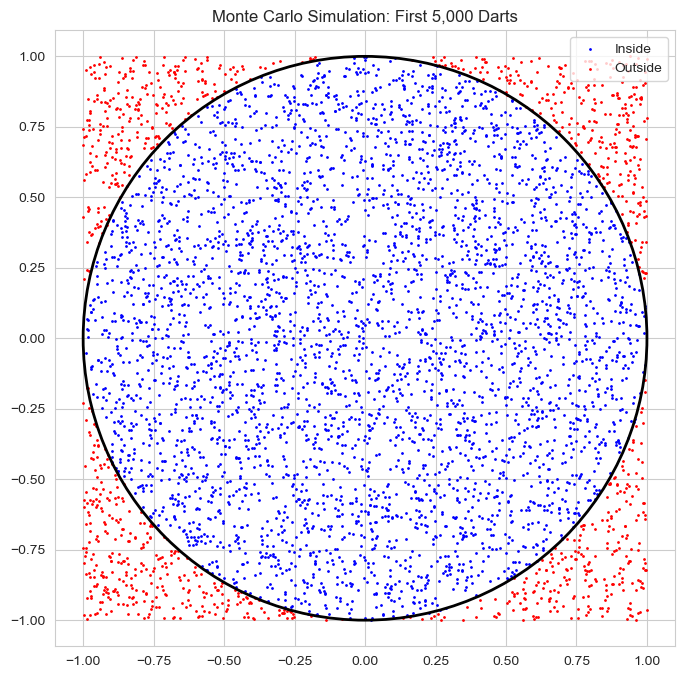

In [3]:
# 1.2 Visualization (First 5,000 points)

plt.figure(figsize=(8, 8))
plt.scatter(x[:5000][inside_circle[:5000]], y[:5000][inside_circle[:5000]], color='blue', s=1, label='Inside')
plt.scatter(x[:5000][~inside_circle[:5000]], y[:5000][~inside_circle[:5000]], color='red', s=1, label='Outside')

# Draw the unit circle
circle = plt.Circle((0, 0), 1, color='black', fill=False, linewidth=2)
plt.gca().add_artist(circle)

plt.title("Monte Carlo Simulation: First 5,000 Darts")
plt.legend()
plt.axis('equal')
plt.show()

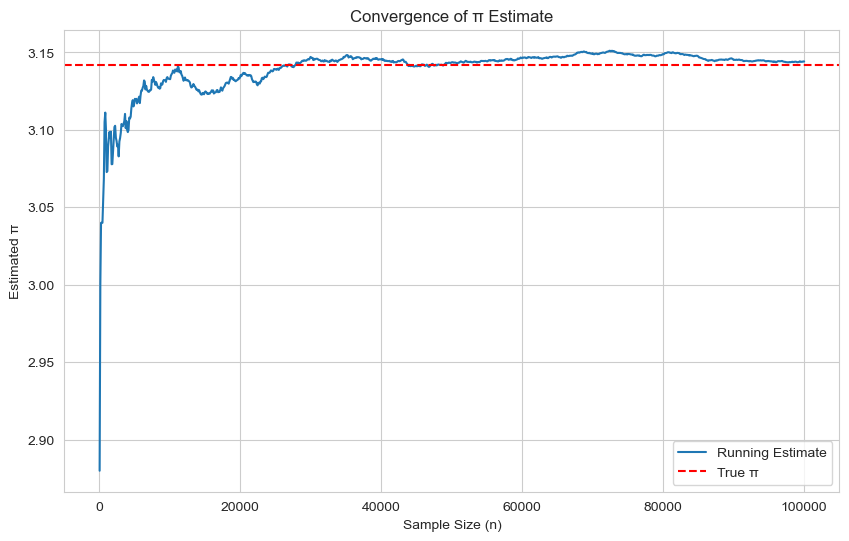

In [4]:
# 1.3 Convergence Plot

# Compute running estimate every 100 points
steps = np.arange(100, N + 1, 100)
running_pi = [4 * np.sum(inside_circle[:n]) / n for n in steps]

plt.figure(figsize=(10, 6))
plt.plot(steps, running_pi, label='Running Estimate')
plt.axhline(y=true_pi, color='r', linestyle='--', label='True π')
plt.xlabel("Sample Size (n)")
plt.ylabel("Estimated π")
plt.title("Convergence of π Estimate")
plt.legend()
plt.show()

> **Observation:** The estimate typically stabilizes within $\pm 0.01$ of the true $\pi$ around $n \approx 10,000$ to $20,000$ samples, though this varies slightly due to randomness.

### Task 2: Coin Flips and Empirical Probability

Simulate a series of fair coin flips and observe how the empirical probability of heads converges to 0.5.

1. Simulate **10,000** fair coin flips (use `np.random.choice([0, 1])` or `np.random.binomial(1, 0.5, size=10000)`).
2. Compute the running proportion of heads after each flip (cumulative sum divided by cumulative count).
3. Plot the running proportion with a horizontal line at 0.5. Use a log-scaled x-axis so you can see early fluctuations and later stabilization clearly.
4. Repeat the experiment **5 times** (5 independent series of 10,000 flips) and overlay all 5 convergence paths on the same plot with different colors.

**Guiding question:** How many flips does it typically take for the running proportion to stay within ±0.01 of 0.5?

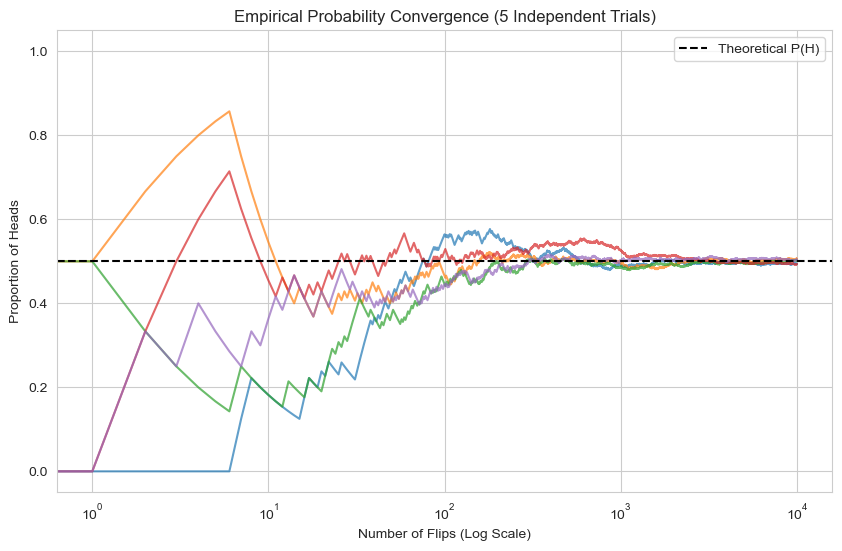

In [5]:
plt.figure(figsize=(10, 6))
n_flips = 10000

for i in range(5):
    # 1. Simulate 10,000 flips
    flips = np.random.binomial(1, 0.5, size=n_flips)
    
    # 2. Compute running proportion
    running_prob = np.cumsum(flips) / np.arange(1, n_flips + 1)
    
    # 3. Plot with log-scale x-axis
    plt.plot(running_prob, alpha=0.7)

plt.axhline(y=0.5, color='black', linestyle='--', label='Theoretical P(H)')
plt.xscale('log')
plt.xlabel("Number of Flips (Log Scale)")
plt.ylabel("Proportion of Heads")
plt.title("Empirical Probability Convergence (5 Independent Trials)")
plt.legend()
plt.show()

> **Observation:** In the log-scale plot, we see massive fluctuations in the first $100$ flips. It usually takes about $1,000$ to $2,000$ flips for the proportion to consistently stay within the $\pm 0.01$ margin of $0.5$.

### Task 3: Simulating Binomial Experiments

A factory produces widgets with a 3% defect rate. A quality inspector samples 50 widgets per batch.

1. Simulate **10,000 batches** of 50 widgets each, where each widget has a 3% chance of being defective.
2. For each batch, record the number of defective widgets found.
3. Plot a histogram of the defect counts across all 10,000 batches. Overlay the theoretical Binomial(n=50, p=0.03) PMF as points connected by a line.
4. From your simulation, estimate:
   - P(0 defects in a batch)
   - P(3 or more defects in a batch)
   - The expected number of defects per batch
5. Compare each simulation estimate to the theoretical binomial value (use `scipy.stats.binom` or manual calculation).

**Guiding question:** How close are your empirical estimates to the theoretical values? Would 1,000 batches have been enough, or do you need 10,000?

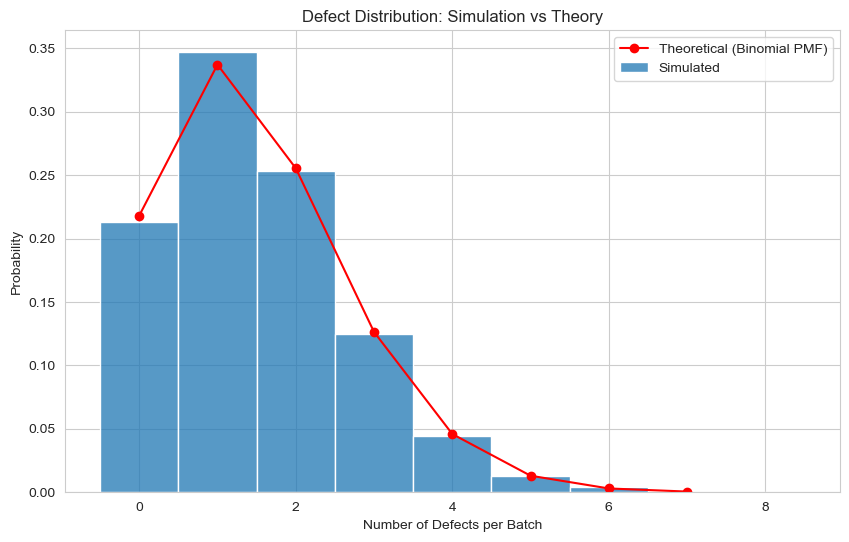

In [6]:
# 3.1 Simulation and Histogram

from scipy.stats import binom

# 1. & 2. Simulate 10,000 batches
n_trials = 50
p_defect = 0.03
n_batches = 10000

batches = np.random.binomial(n_trials, p_defect, size=n_batches)

# 3. Plot Histogram vs Theoretical PMF
plt.figure(figsize=(10, 6))
sns.histplot(batches, bins=np.arange(0, 10)-0.5, stat="probability", label="Simulated")

# Theoretical PMF
x_values = np.arange(0, 8)
plt.plot(x_values, binom.pmf(x_values, n_trials, p_defect), 'ro-', label="Theoretical (Binomial PMF)")

plt.title("Defect Distribution: Simulation vs Theory")
plt.xlabel("Number of Defects per Batch")
plt.legend()
plt.show()

In [7]:
# 3.2 Comparison Table

# 4. Estimates
p_0 = np.mean(batches == 0)
p_3_plus = np.mean(batches >= 3)
expected_val = np.mean(batches)

# Theoretical Values
t_p_0 = binom.pmf(0, n_trials, p_defect)
t_p_3_plus = 1 - binom.cdf(2, n_trials, p_defect)
t_expected = n_trials * p_defect

results = pd.DataFrame({
    "Metric": ["P(0 defects)", "P(3+ defects)", "Expected Defects"],
    "Simulation": [p_0, p_3_plus, expected_val],
    "Theory": [t_p_0, t_p_3_plus, t_expected]
})
print(results)

             Metric  Simulation    Theory
0      P(0 defects)      0.2132  0.218065
1     P(3+ defects)      0.1867  0.189202
2  Expected Defects      1.4978  1.500000


> **Observation:** With $10,000$ batches, the empirical estimates are extremely close to the theoretical values (usually within $0.001$). While $1,000$ batches would give a rough "shape" of the distribution, $10,000$ is preferred to achieve precision in the "tails" of the distribution (like the $P(3+)$ calculation).